<a href="https://colab.research.google.com/github/cleanesantos/aulas-modelos-datascience/blob/main/Regressao_Linear_M%C3%BAltipla_Aula_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regressão linear: publicidade, vendas e preços de imóveis
## iCEV | Aula prática em Python

**Parte 1:** regressão linear simples para analisar a relação entre investimento em publicidade na TV e vendas.

**Parte 2:** regressão linear simples e múltipla para analisar a relação entre área, localização e valor dos imóveis.

Abra o arquivo no Google Colab pela opção de upload de notebook. As duas bases de dados estão incorporadas ao arquivo. Não é necessário baixar ou enviar CSVs.

Execute as células na ordem ou selecione **Ambiente de execução > Executar tudo**.

### Bases de dados disponiveis no Kaggle.

### Bases de dados disponíveis no repositório da disciplina

- **Publicidade e vendas:** [advertising.csv](https://github.com/cleanesantos/aulas-modelos-datascience/blob/main/advertising.csv).


- **Imóveis:** [dataset.csv](https://github.com/cleanesantos/aulas-modelos-datascience/blob/main/dataset.csv).

## 1. O que queremos estimar?
Uma regressão descreve uma associação entre uma variável resposta e uma ou mais variáveis explicativas.

$$Y_i=\beta_0+\beta_1X_i+\varepsilon_i$$

$$\widehat{Y}_i=\widehat{\beta}_0+\widehat{\beta}_1X_i$$

**X:** variável explicativa.

**Y:** variável resposta.

**Intercepto:** previsão quando X = 0.

**Coeficiente angular:** variação na previsão associada ao aumento de uma unidade em X.

**Resíduo:** observado menos previsto.

A regressão, por si só, não demonstra causalidade.

## 2. Bibliotecas
Pandas organiza as tabelas; Matplotlib e Seaborn produzem gráficos; scikit-learn ajusta e avalia os modelos; statsmodels apresenta resultados estatísticos.

In [3]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 5)

# Parte 2. Área, localização e preço dos imóveis
O notebook original descreve 5.000 imóveis ofertados no Rio de Janeiro, com **Valor** (R$), **Area** (m²), **Dist_Praia** (km) e **Dist_Farmacia** (km). Essa descrição é do material enviado; não houve verificação independente da amostragem.

Primeiro ajustaremos Valor em função apenas de Area. Depois avançaremos para o modelo múltiplo com transformações usado no original.

A base de imóveis está incorporada na célula abaixo, em formato compactado. Ao executar, ela é descompactada e carregada em um DataFrame. São 5.000 observações e quatro variáveis. A cópia pública foi obtida no repositório RafaelxFernandes/Data-Science-e-Deep-Learning. Não foi possível verificar identidade integral com o arquivo original da Alura.

In [4]:
url_imoveis = "https://raw.githubusercontent.com/cleanesantos/aulas-modelos-datascience/main/dataset.csv"

imoveis = pd.read_csv(url_imoveis, sep=";")

imoveis.head()

,Valor,Area,Dist_Praia,Dist_Farmacia
0,4600000,280,0.240925,0.793637
1,900000,208,0.904136,0.134494
2,2550000,170,0.059525,0.423318
3,550000,100,2.883181,0.525064
4,2200000,164,0.239758,0.192374


## 12. Análise inicial
Observe a dispersão dos preços e a associação entre as variáveis. Pontos extremos não devem ser excluídos automaticamente.

,Valor,Area,Dist_Praia,Dist_Farmacia
count,5000.00,5000.00,5000.00,5000.00
mean,1402926.39,121.94,3.02,0.50
std,1883268.85,90.54,3.17,0.29
min,75000.00,16.00,0.00,0.00
25%,460000.00,70.00,0.44,0.24
50%,820000.00,93.00,1.48,0.50
75%,1590000.00,146.00,5.61,0.75
max,25000000.00,2000.00,17.96,1.00


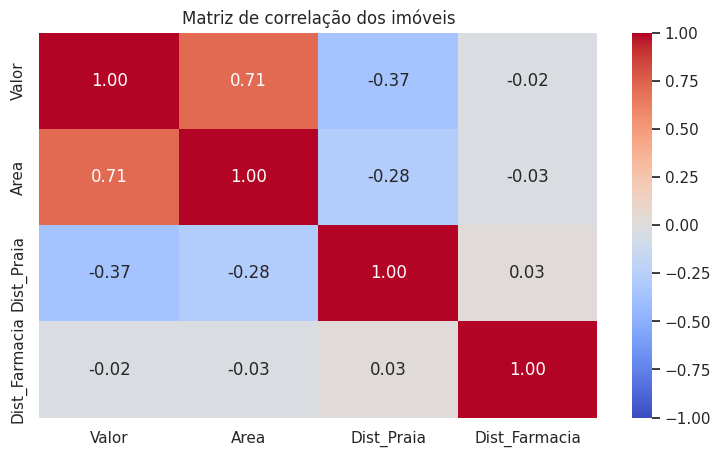

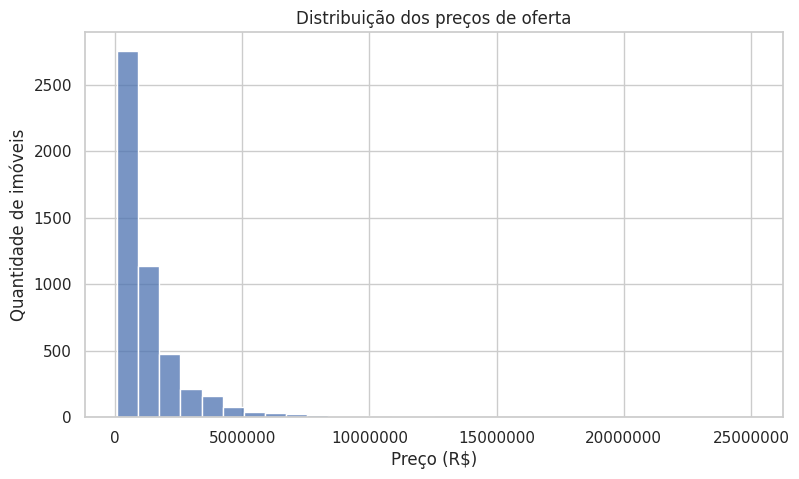

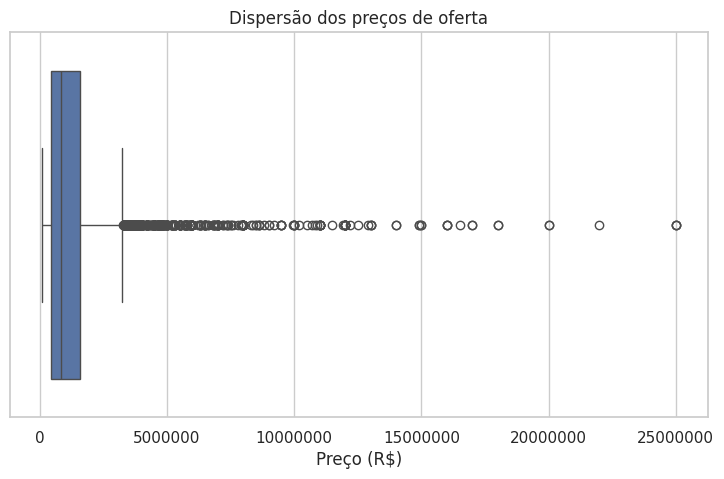

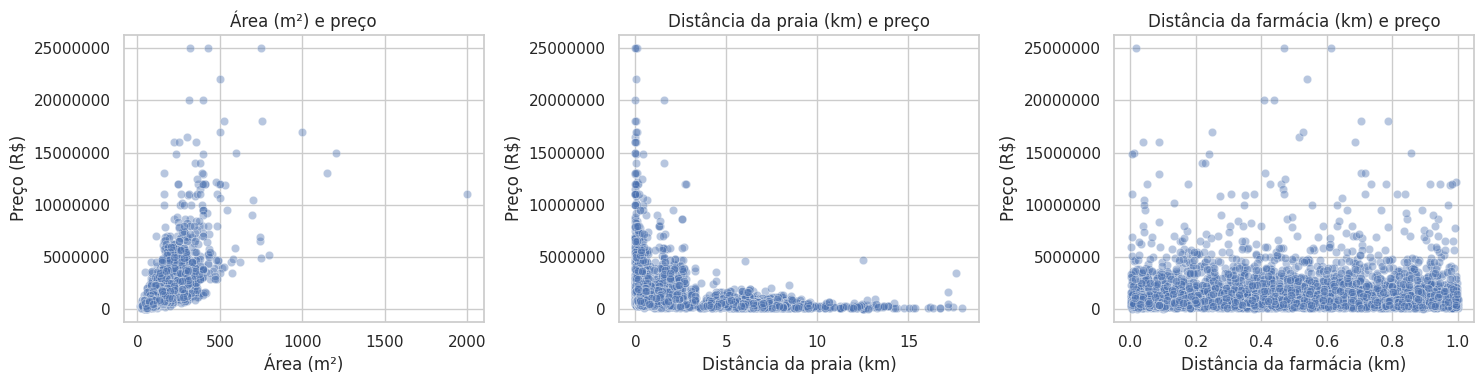

In [6]:
display(imoveis.describe().round(2))

sns.heatmap(imoveis.corr(), annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlação dos imóveis")
plt.show()

sns.histplot(data=imoveis, x="Valor", bins=30)
plt.title("Distribuição dos preços de oferta")
plt.xlabel("Preço (R$)")
plt.ylabel("Quantidade de imóveis")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

sns.boxplot(data=imoveis, x="Valor")
plt.title("Dispersão dos preços de oferta")
plt.xlabel("Preço (R$)")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, coluna, rotulo in zip(
    axes,
    ["Area", "Dist_Praia", "Dist_Farmacia"],
    ["Área (m²)", "Distância da praia (km)", "Distância da farmácia (km)"]
):
    sns.scatterplot(data=imoveis, x=coluna, y="Valor", ax=ax, alpha=0.4)
    ax.set(title=f"{rotulo} e preço", xlabel=rotulo, ylabel="Preço (R$)")
    ax.ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()

## 13. Regressão simples: área e preço
$$\widehat{Valor}=\widehat{\beta}_0+\widehat{\beta}_1Area$$
O coeficiente representa a variação no preço previsto, em reais, por m² adicional. A localização ainda não está controlada. Usaremos os mesmos imóveis no treino e no teste de todos os modelos desta parte.

In [7]:
indice_treino, indice_teste = train_test_split(
    imoveis.index, test_size=0.20, random_state=2811
)

im_treino = imoveis.loc[indice_treino]
im_teste = imoveis.loc[indice_teste]

modelo_area = LinearRegression()
modelo_area.fit(im_treino[["Area"]], im_treino["Valor"])

print(f"Intercepto (b0): {modelo_area.intercept_:.2f}")
print(f"Coeficiente de Área (b1): {modelo_area.coef_[0]:.2f}")

Intercepto (b0): -424695.90
Coeficiente de Área (b1): 15091.63


### Interpretação dos coeficientes

A equação ajustada é:

$$
\widehat{\text{Valor}} = -424.695{,}90 + 15.091{,}63 \times \text{Área}
$$

O **coeficiente de Área** indica que cada **1 m² adicional** está associado a um aumento de aproximadamente **R$ 15.091,63 no preço previsto**. Como o modelo utiliza apenas a área, essa associação não controla diferenças de localização ou outras características dos imóveis.

O **intercepto negativo** corresponde ao preço previsto para uma área de 0 m². Esse valor não tem interpretação prática como preço de um imóvel; ele posiciona a reta ajustada. Para áreas suficientemente pequenas, o modelo pode produzir preços negativos, evidenciando uma limitação.

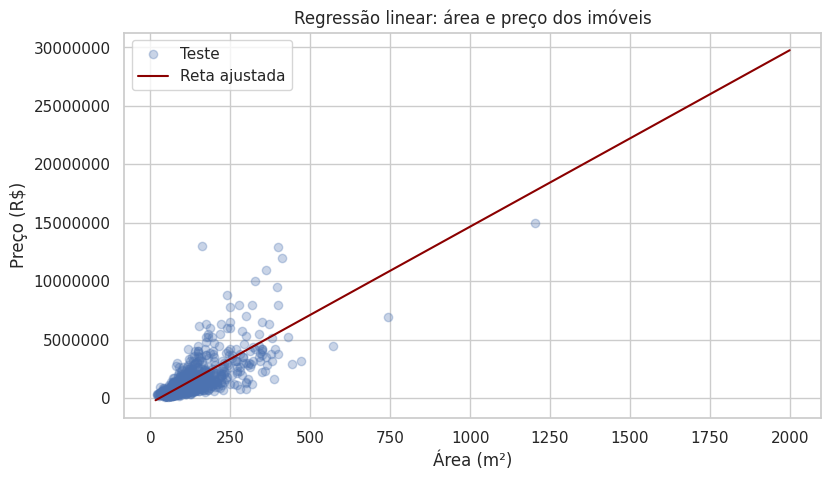

In [8]:
grade_area = pd.DataFrame({
    "Area": np.linspace(imoveis["Area"].min(), imoveis["Area"].max(), 100)
})

plt.scatter(im_teste["Area"], im_teste["Valor"], alpha=0.3, label="Teste")
plt.plot(grade_area["Area"], modelo_area.predict(grade_area),
         color="darkred", label="Reta ajustada")

plt.title("Regressão linear: área e preço dos imóveis")
plt.xlabel("Área (m²)")
plt.ylabel("Preço (R$)")
plt.ticklabel_format(style="plain", axis="y")
plt.legend()
plt.show()

### Interpretação da reta ajustada

A reta indica uma associação positiva entre área e preço: imóveis com maior área apresentam preços previstos mais altos.

A maioria dos imóveis do teste está concentrada nas áreas menores. Para áreas semelhantes, há preços bastante diferentes, mostrando que a área sozinha não explica toda a variação dos valores.

Alguns pontos estão distantes da reta, indicando erros elevados de previsão. Nas áreas maiores, há poucas observações de teste, o que limita a avaliação do modelo nessa faixa.

Esses resultados motivam investigar variáveis de localização em uma regressão múltipla. A melhora deverá ser verificada pelas métricas de avaliação.

In [9]:
prev_area = modelo_area.predict(im_teste[["Area"]])

print("R²:", round(r2_score(im_teste["Valor"], prev_area), 4))
print("MAE (R$):", round(mean_absolute_error(im_teste["Valor"], prev_area), 2))
print("RMSE (R$):", round(np.sqrt(mean_squared_error(im_teste["Valor"], prev_area)), 2))

R²: 0.5364
MAE (R$): 617271.84
RMSE (R$): 1053564.63


### Avaliação do modelo inicial

O **R² de 0,5364** indica que o modelo com apenas a área explica aproximadamente **53,64% da variação dos preços no conjunto de teste**. Isso não representa um percentual de acerto.

O **MAE de R$ 617.271,84** indica a magnitude média das diferenças absolutas entre os preços observados e previstos.

O **RMSE de R$ 1.053.564,63**, bastante superior ao MAE, indica que erros grandes têm peso importante no resultado.

A área contribui para prever os preços, mas o modelo ainda apresenta erros elevados em reais. Esses resultados serão a referência para avaliar se a inclusão da localização e as transformações melhoram as previsões. A comparação deve usar os mesmos imóveis de teste e métricas na escala original, em reais.

## 14. Por que transformar?

A transformação logarítmica pode reduzir a assimetria e representar relações proporcionais entre as variáveis.

Usaremos o logaritmo natural do preço e da área. Para as distâncias, usaremos o logaritmo de (1 + distância), permitindo incluir valores iguais a zero.

A transformação não garante um modelo melhor. Sua adequação será avaliada pelos resíduos e pelos erros de previsão no conjunto de teste, calculados em reais.

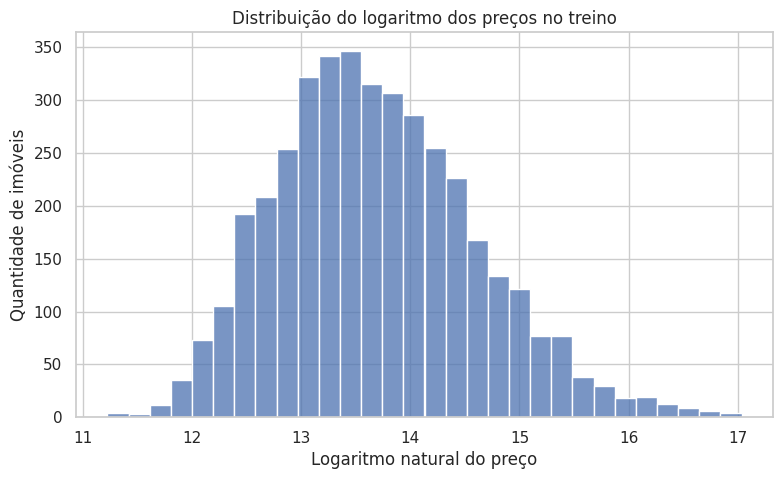

In [10]:
log_treino = np.log1p(im_treino[["Dist_Praia", "Dist_Farmacia"]])
log_treino["Area"] = np.log(im_treino["Area"])

log_teste = np.log1p(im_teste[["Dist_Praia", "Dist_Farmacia"]])
log_teste["Area"] = np.log(im_teste["Area"])

y_log_treino = np.log(im_treino["Valor"])
y_log_teste = np.log(im_teste["Valor"])

sns.histplot(y_log_treino, bins=30)
plt.title("Distribuição do logaritmo dos preços no treino")
plt.xlabel("Logaritmo natural do preço")
plt.ylabel("Quantidade de imóveis")
plt.show()

In [11]:
modelo_area_log = LinearRegression()
modelo_area_log.fit(log_treino[["Area"]], y_log_treino)

print("Intercepto:", round(modelo_area_log.intercept_, 4))
print("Coeficiente de log(Área):", round(modelo_area_log.coef_[0], 4))

prev_area_log = modelo_area_log.predict(log_teste[["Area"]])

print("\nMétricas na escala logarítmica:")
print("R²:", round(r2_score(y_log_teste, prev_area_log), 4))
print("MAE:", round(mean_absolute_error(y_log_teste, prev_area_log), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_log_teste, prev_area_log)), 4))

Intercepto: 7.7536
Coeficiente de log(Área): 1.2845

Métricas na escala logarítmica:
R²: 0.6151
MAE: 0.4299
RMSE: 0.5353


In [12]:
prev_area_reais = np.exp(prev_area_log)

print("R²:", round(r2_score(im_teste["Valor"], prev_area_reais), 4))
print("MAE (R$):", round(mean_absolute_error(im_teste["Valor"], prev_area_reais), 2))
print("RMSE (R$):", round(np.sqrt(mean_squared_error(im_teste["Valor"], prev_area_reais)), 2))

R²: 0.5085
MAE (R$): 565813.6
RMSE (R$): 1084844.31


### Comparação do modelo simples com e sem logaritmo

A transformação logarítmica apresentou uma melhora parcial nas previsões:

O **MAE diminuiu aproximadamente 8,3%**, indicando menor erro absoluto médio. Entretanto, o **RMSE aumentou cerca de 3%** e o **R² diminuiu**, mostrando pior desempenho quando os erros grandes recebem maior peso.

O R² de **0,6151 na escala logarítmica** mede a variação do logaritmo dos preços e não deve ser comparado diretamente com o R² em reais.

Portanto, a transformação não melhorou todas as métricas. O próximo passo será incluir as variáveis de localização para verificar se elas acrescentam informação à previsão dos preços.

## 15. Modelo múltiplo completo
$$\widehat{\ln(Valor)}=\widehat{\beta}_0+\widehat{\beta}_1\ln(Area)+\widehat{\beta}_2\ln(1+Dist\_Praia)+\widehat{\beta}_3\ln(1+Dist\_Farmacia)$$
Agora há três variáveis explicativas. Os coeficientes são associações condicionais às outras variáveis incluídas.

In [13]:
ols_im_completo = sm.OLS(y_log_treino, sm.add_constant(log_treino)).fit()
print(ols_im_completo.summary())
modelo_im_completo = LinearRegression().fit(log_treino, y_log_treino)

                            OLS Regression Results                            
Dep. Variable:                  Valor   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     5495.
Date:                Tue, 06 Oct 2026   Prob (F-statistic):               0.00
Time:                        18:52:44   Log-Likelihood:                -2044.9
No. Observations:                4000   AIC:                             4098.
Df Residuals:                    3996   BIC:                             4123.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             9.3417      0.060    154.734

### Interpretação da regressão múltipla com logaritmos

O modelo foi ajustado com **4.000 imóveis do treino**, utilizando o logaritmo do preço, o logaritmo da área e o logaritmo de (1 + distância):

$$
\widehat{\ln(\text{Valor})}
= 9{,}3417
+ 1{,}0580\ln(\text{Área})
- 0{,}4905\ln(1+\text{Distância da praia})
- 0{,}0167\ln(1+\text{Distância da farmácia})
$$

O **R² de 0,805** indica que o modelo explica aproximadamente **80,5% da variação do logaritmo dos preços no treino**. Esse resultado não representa desempenho no teste nem é diretamente comparável ao R² dos preços em reais.

**Área:** mantendo as distâncias constantes, um aumento de 1% na área está associado a aproximadamente **1,058% de aumento no preço previsto**. O coeficiente é estatisticamente significativo, com valor-p inferior a 0,001.

**Distância da praia:** mantendo as demais variáveis constantes, maiores distâncias estão associadas a menores preços previstos. O coeficiente é significativo, com valor-p inferior a 0,001. Como a transformação utiliza log(1 + distância), ele não representa uma redução fixa por quilômetro.

**Distância da farmácia:** o valor-p de **0,603** e o intervalo de confiança que inclui zero indicam ausência de evidência suficiente de associação nessa especificação, após considerar área e distância da praia. Isso não comprova que a variável seja irrelevante em qualquer contexto.

Os testes Omnibus e Jarque-Bera rejeitam a hipótese de normalidade dos erros ao nível de 5%. Os erros padrão apresentados são convencionais (`nonrobust`), e a análise dos resíduos continua necessária para avaliar as hipóteses da inferência.

Para verificar se as previsões melhoraram, calcularemos **R², MAE e RMSE em reais nos mesmos imóveis de teste**.

## 16. Modelo reduzido variavel nao signiifcativa
Retiraremos a distância à farmácia porque seu coeficiente não foi estatisticamente significativo ao nível de 5% (valor-p = 0,603). Ajustaremos o modelo sem essa variável para comparar os resultados.

In [14]:
variaveis_reduzidas = ["Area", "Dist_Praia"]

ols_im_reduzido = sm.OLS(
    y_log_treino,
    sm.add_constant(log_treino[variaveis_reduzidas])
).fit()

print(ols_im_reduzido.summary())

modelo_im_reduzido = LinearRegression()
modelo_im_reduzido.fit(log_treino[variaveis_reduzidas], y_log_treino)

                            OLS Regression Results                            
Dep. Variable:                  Valor   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     8244.
Date:                Tue, 06 Oct 2026   Prob (F-statistic):               0.00
Time:                        18:55:22   Log-Likelihood:                -2045.1
No. Observations:                4000   AIC:                             4096.
Df Residuals:                    3997   BIC:                             4115.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.3349      0.059    158.353      0.0

LinearRegression()

### Resultado do modelo sem distância à farmácia

Após retirar a distância à farmácia, o **R² do treino permaneceu em 0,805**, na precisão apresentada. O modelo mantém praticamente a mesma capacidade de explicar a variação do logaritmo dos preços, utilizando duas variáveis.

O coeficiente de **log(Área) é 1,0581**: mantendo a distância da praia constante, um aumento de 1% na área está associado a aproximadamente 1,0581% de aumento no preço previsto.

O coeficiente de **log(1 + distância da praia) é −0,4906**: mantendo a área constante, maiores distâncias da praia estão associadas a menores preços previstos. Ambos os coeficientes apresentam valor-p inferior a 0,001.

O **AIC diminuiu de 4098 para 4096** e o **BIC de 4123 para 4115**, favorecendo a especificação mais simples nesses critérios.

A retirada da variável preservou o ajuste no treino. Ainda precisamos calcular as métricas no teste para verificar o desempenho das previsões em reais.

## 18. Voltando à escala de reais

O modelo calcula as previsões na escala logarítmica. A função `np.exp()`, da biblioteca NumPy, converte essas previsões para reais.

Com os valores nessa escala, podemos comparar os preços previstos com os preços observados e calcular R², MAE e RMSE.

Essa conversão direta não estima necessariamente o preço médio, mas permite avaliar os erros das previsões em reais.

In [21]:
prev_log_reduzido = modelo_im_reduzido.predict(log_teste[variaveis_reduzidas])
prev_reais_reduzido = np.exp(prev_log_reduzido)

## 19. Comparando modelos na mesma escala
Compare MAE e RMSE em reais, nos mesmos imóveis do teste. R² em log e R² em reais têm denominadores diferentes e não devem ser comparados diretamente como se fossem a mesma resposta.

In [22]:
def avaliar_reais(nome, observado, previsto):
    return {"Modelo": nome, "R² em reais": r2_score(observado, previsto),
            "MAE (R$)": mean_absolute_error(observado, previsto),
            "RMSE (R$)": np.sqrt(mean_squared_error(observado, previsto))}
comparacao_imoveis = pd.DataFrame([
    avaliar_reais("Simples: área", im_teste.Valor, prev_area),
    avaliar_reais("Múltiplo completo: log + correção", im_teste.Valor, prev_reais_completo),
    avaliar_reais("Múltiplo reduzido: log + correção", im_teste.Valor, prev_reais_reduzido)])
display(comparacao_imoveis.round(3))
print("R² do reduzido na escala log:", round(r2_score(y_log_teste, prev_log_reduzido), 4))

,Modelo,R² em reais,MAE (R$),RMSE (R$)
0,Simples: área,0.536,617271.836,1053564.631
1,Múltiplo completo: log + correção,0.613,492141.689,963171.021
2,Múltiplo reduzido: log + correção,0.627,471065.582,945586.044


R² do reduzido na escala log: 0.7904
